In [1]:
import numpy as np
import sys
import matplotlib.pyplot as plt
import torch
import torch_geometric
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, EdgeConv, DynamicEdgeConv
from torcheval.metrics import MulticlassAUROC, MulticlassAccuracy
from itertools import combinations


sys.path.append("../")

In [2]:
DATA_DIR = "../mu3e_trigger_data"
MODEL_DIR = "../models"
SIGNAL_PIXEL_FILE = f"{DATA_DIR}/sig_pixel_spacetime.npy"
BACKGROUND_PIXEL_FILE = f"{DATA_DIR}/bg_pixel_spacetime.npy"
SIGNAL_MPPC_FILE = f"{DATA_DIR}/sig_mppc_spacetime.npy"

BACKGROUND_MPPC_FILE = f"{DATA_DIR}/bg_mppc_spacetime.npy"
SIGNAL_ONLY_PIXEL_FILE = f"{DATA_DIR}/sig_only_pixel_spacetime.npy"
SIGNAL_ONLY_MPPC_FILE = f"{DATA_DIR}/sig_only_mppc_spacetime.npy"

SIGNAL_PIXEL_WITH_LAYER_FILE = f"{DATA_DIR}/sig_with_layer_pixel_spacetime.npy"
BACKGROUND_PIXEL_WITH_LAYER_FILE = f"{DATA_DIR}/bg_with_layer_pixel_spacetime.npy"
SIGNAL_ONLY_PIXEL_WITH_LAYER_FILE = f"{DATA_DIR}/sig_only_with_layer_pixel_spacetime.npy"

bg_pixel_spacetime = np.load(BACKGROUND_PIXEL_FILE)
bg_mppc_spacetime = np.load(BACKGROUND_MPPC_FILE)
sig_pixel_spacetime = np.load(SIGNAL_PIXEL_FILE)
sig_mppc_spacetime = np.load(SIGNAL_MPPC_FILE)
sig_only_pixel_spacetime = np.load(SIGNAL_ONLY_PIXEL_FILE)
sig_only_mppc_spacetime = np.load(SIGNAL_ONLY_MPPC_FILE)
sig_pixel_spacetime_with_layer = np.load(SIGNAL_PIXEL_WITH_LAYER_FILE)
bg_pixel_spacetime_with_layer = np.load(BACKGROUND_PIXEL_WITH_LAYER_FILE)
sig_only_pixel_spacetime_with_layer = np.load(SIGNAL_ONLY_PIXEL_WITH_LAYER_FILE)



In [3]:
sig_only_pixel_time = sig_only_pixel_spacetime[:,:, -1]
sig_only_mppc_time = sig_only_mppc_spacetime[:,:, -1]

In [4]:
pixel_time_range = np.zeros(len(sig_only_pixel_spacetime))
for event_id in range(len(sig_only_pixel_spacetime)):
    if np.all(sig_only_pixel_time[event_id] == -1):
        pixel_time_range[event_id] = -1
        continue
    pixel_time_range[event_id] = (
        np.max(sig_only_pixel_time[event_id][sig_only_pixel_time[event_id] != -1])
        - np.min(sig_only_pixel_time[event_id][sig_only_pixel_time[event_id] != -1]
    ))
num_pixel_hits = np.sum(sig_only_pixel_time != -1, axis=1)

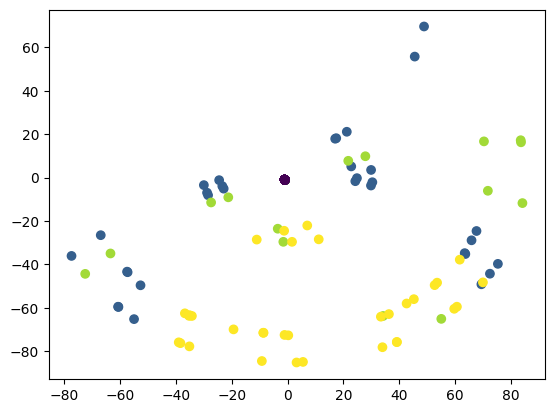

In [5]:
plt.scatter(sig_only_pixel_spacetime[pixel_time_range > 16, :, 0][0], sig_only_pixel_spacetime[pixel_time_range > 16, :, 1][0], c = sig_only_pixel_time[pixel_time_range > 16][0])

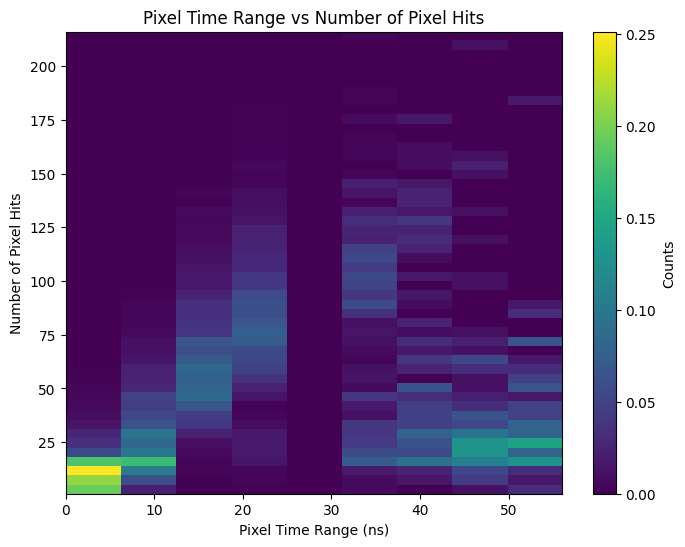

In [6]:
hist, x_edges, y_edges = np.histogram2d(
    pixel_time_range[num_pixel_hits > 0],
    num_pixel_hits[num_pixel_hits > 0],
    bins = (9, 50)
)
hist /= (np.sum(hist, axis=1, keepdims=True) +1e-1) # Normalize each column

plt.figure(figsize=(8,6))
plt.imshow(hist.T, origin='lower', aspect='auto',
           extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]],
           cmap='viridis')
plt.colorbar(label='Counts')
plt.xlabel('Pixel Time Range (ns)')
plt.ylabel('Number of Pixel Hits')
plt.title('Pixel Time Range vs Number of Pixel Hits')
plt.show()

In [7]:
import numpy as np

def count_edges_per_event_time_layer_filtered(events: np.ndarray):
    num_edges = np.zeros(len(events), dtype=np.int64)

    for event_idx, event in enumerate(events):
        valid_hits = event[event[:, -1] != -1]
        if valid_hits.shape[0] < 2:
            continue

        times = valid_hits[:, -1].astype(int)
        layers = valid_hits[:, -2].astype(int) - 1

        # Group by (time, layer) → how many hits in each
        # There are only 4 layers, so shape = (n_times, 4)
        unique_times, inv = np.unique(times, return_inverse=True)
        counts = np.zeros((len(unique_times), 4), dtype=np.int64)
        np.add.at(counts, (inv, layers), 1)

        # Count edges between adjacent layers (0–1, 1–2, 2–3)
        edges = np.sum(counts[:, :-1] * counts[:, 1:])

        num_edges[event_idx] = 2 * edges

    return num_edges


def count_edges_per_event_time_filtered(events: np.ndarray):
    """
    Count edges per event:
      - Only hits with valid time (last col != -1) are used
      - Within each time slice, all hits are fully connected
      - Edges are directed, so n*(n-1) edges per slice

    Args:
        events: np.ndarray [num_events, num_hits, feature_dim]
                padded with -1 in the last column (time)

    Returns:
        np.ndarray: [num_events] edge counts
    """
    num_edges = np.zeros(len(events), dtype=np.int64)

    for event_idx, event in enumerate(events):
        valid_hits = event[event[:, -1] != -1]
        if valid_hits.shape[0] < 2:
            continue

        times = valid_hits[:, -1].astype(int)

        # Group by time → count hits per time slice
        _, counts = np.unique(times, return_counts=True)

        # Fully connected within each slice: n * (n-1)
        edges = np.sum(counts * (counts - 1))

        num_edges[event_idx] = edges

    return num_edges


import numpy as np

def count_edges_per_event_layer_filtered(events: np.ndarray):
    """
    Count edges per event:
      - Only hits with valid time (last col != -1) are used
      - Edges only between adjacent layers (layer diff = 1)
      - Multiply by 2 because edges are bidirectional

    Args:
        events: np.ndarray [num_events, num_hits, feature_dim]
                padded with -1 in the last column (time)

    Returns:
        np.ndarray: [num_events] edge counts
    """
    num_edges = np.zeros(len(events), dtype=np.int64)

    for event_idx, event in enumerate(events):
        valid_hits = event[event[:, -1] != -1]
        if valid_hits.shape[0] < 2:
            continue

        layers = valid_hits[:, -2].astype(int) - 1  # Assuming layers are 1-indexed

        # Count how many hits in each of 4 layers
        counts = np.bincount(layers, minlength=4)

        # Edges only between adjacent layers (0–1, 1–2, 2–3)
        edges = np.sum(counts[:-1] * counts[1:])

        # Bidirectional → multiply by 2
        num_edges[event_idx] = 2 * edges

    return num_edges

def count_edges_per_event(events: np.array):
    """
    Convert a batch of events (padded) to a single PyG Batch object with variable number of graphs per event.
    Time is assumed to be at the last column (-1).

    Args:
        events (torch.Tensor): [num_events, num_hits, feature_dim] padded with -1
                               last column must be time

    Returns:
        Batch: PyG Batch object containing all graphs from all events
    """
    num_edges = np.zeros(len(events))

    for event_idx, event in enumerate(events):
        valid_hits = event[event[:, -1] != -1]
        num_nodes = valid_hits.shape[0]

        edges = num_nodes * (num_nodes - 1)  # Fully connected graph
        num_edges[event_idx] += edges
    return num_edges

In [8]:
signal_fully_connected_edges = count_edges_per_event(sig_pixel_spacetime_with_layer)
background_fully_connected_edges = count_edges_per_event(bg_pixel_spacetime_with_layer)
signal_time_filtered_edges = count_edges_per_event_time_filtered(sig_pixel_spacetime_with_layer)
background_time_filtered_edges = count_edges_per_event_time_filtered(bg_pixel_spacetime_with_layer)
signal_layer_filtered_edges = count_edges_per_event_layer_filtered(sig_pixel_spacetime_with_layer)
background_layer_filtered_edges = count_edges_per_event_layer_filtered(bg_pixel_spacetime_with_layer)
signal_time_layer_filtered_edges = count_edges_per_event_time_layer_filtered(sig_pixel_spacetime_with_layer)
background_time_layer_filtered_edges = count_edges_per_event_time_layer_filtered(bg_pixel_spacetime_with_layer)
signal_only_fully_connected_edges = count_edges_per_event(sig_only_pixel_spacetime)
signal_only_time_filtered_edges = count_edges_per_event_time_filtered(sig_only_pixel_spacetime)
signal_only_layer_filtered_edges = count_edges_per_event_layer_filtered(sig_only_pixel_spacetime_with_layer)
signal_only_time_layer_filtered_edges = count_edges_per_event_time_layer_filtered(sig_only_pixel_spacetime_with_layer)

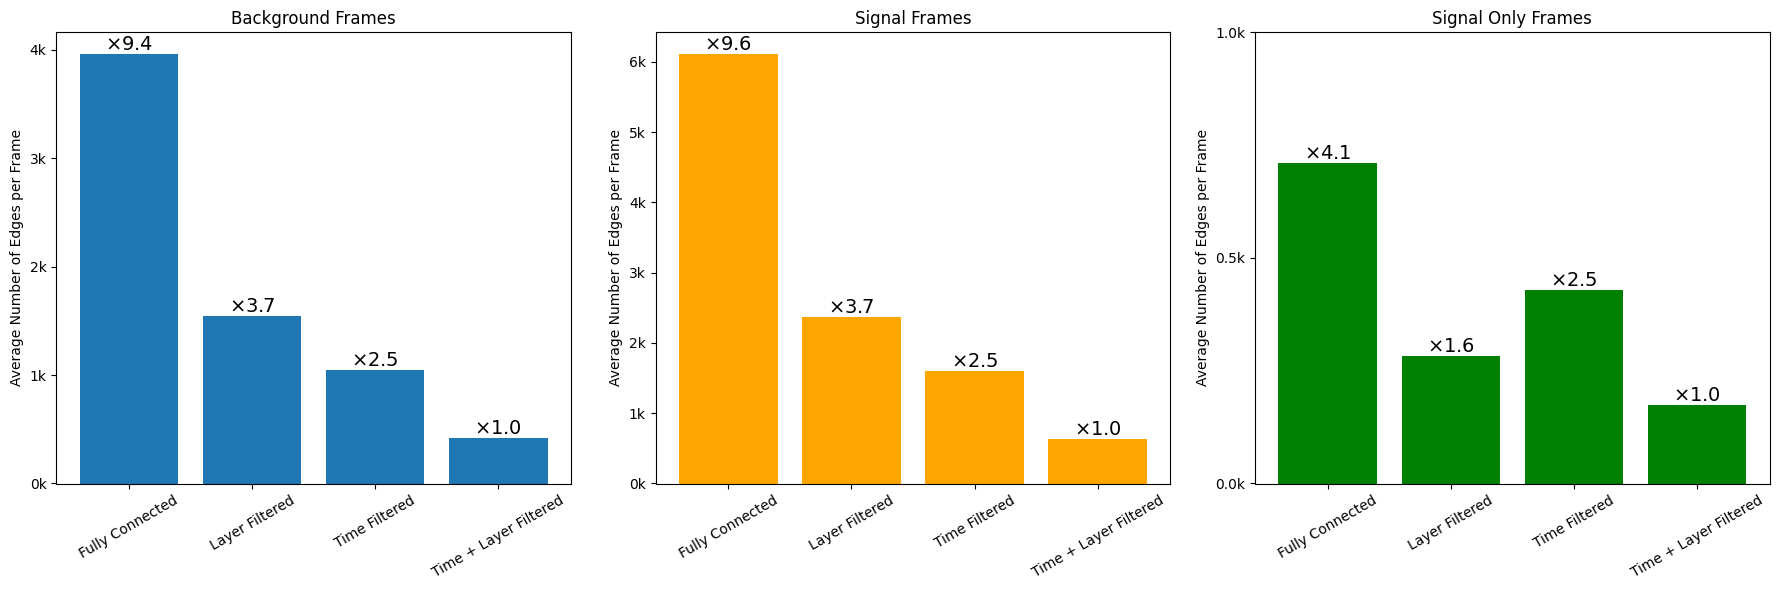

In [9]:
fig, ax = plt.subplots(1, 3, figsize=(18, 6))
edge_count = np.array([background_fully_connected_edges.mean(), background_layer_filtered_edges.mean(), background_time_filtered_edges.mean(), background_time_layer_filtered_edges.mean()])
ax[0].bar(np.arange(4), edge_count)
ax[0].set_ylabel('Average Number of Edges per Frame')
ax[0].set_title('Background Frames')
ax[0].set_xticks(np.arange(4))
ax[0].set_xticklabels(['Fully Connected', 'Layer Filtered', 'Time Filtered', 'Time + Layer Filtered'], rotation=30)
y_ticks = np.arange(1, np.ceil(np.max(edge_count) + 500), step=1000)
ax[0].set_yticks(y_ticks)
ax[0].set_yticklabels([f"{int(y/1000)}k" for y in y_ticks])


# Annotate each bar with the difference to the time+layer filtered version
for i in range(4):
    factor = edge_count[i] / edge_count[3]
    ax[0].text(i, edge_count[i], r"$\times$" + f"{factor:.1f}", ha='center', va='bottom', fontsize=14)

edge_count = np.array([signal_fully_connected_edges.mean(), signal_layer_filtered_edges.mean(), signal_time_filtered_edges.mean(), signal_time_layer_filtered_edges.mean()])
ax[1].bar(np.arange(4), edge_count, color='orange')
ax[1].set_ylabel('Average Number of Edges per Frame')
ax[1].set_title('Signal Frames')
ax[1].set_xticks(np.arange(4))
ax[1].set_xticklabels(['Fully Connected', 'Layer Filtered', 'Time Filtered', 'Time + Layer Filtered'], rotation=30)
for i in range(4):
    factor = edge_count[i] / edge_count[3]
    ax[1].text(i, edge_count[i], r"$\times$" + f"{factor:.1f}", ha='center', va='bottom', fontsize=14)
ax[1].set_yticks(np.arange(0, np.ceil(np.max(edge_count) + 500), step=1000))
y_ticks = np.arange(1, np.ceil(np.max(edge_count) + 500), step=1000)
ax[1].set_yticks(y_ticks)
ax[1].set_yticklabels([f"{int(y/1000)}k" for y in y_ticks])

edge_count = np.array([signal_only_fully_connected_edges.mean(), signal_only_layer_filtered_edges.mean(), signal_only_time_filtered_edges.mean(), signal_only_time_layer_filtered_edges.mean()])
ax[2].bar(np.arange(4), edge_count, color='green')
ax[2].set_ylabel('Average Number of Edges per Frame')
ax[2].set_title('Signal Only Frames')
ax[2].set_xticks(np.arange(4))
ax[2].set_xticklabels(['Fully Connected', 'Layer Filtered', 'Time Filtered', 'Time + Layer Filtered'], rotation=30)
for i in range(4):
    factor = edge_count[i] / edge_count[3]
    ax[2].text(i, edge_count[i], r"$\times$" + f"{factor:.1f}", ha='center', va='bottom', fontsize=14)
y_ticks = np.arange(1, np.ceil(np.max(edge_count) + 500), step=500)
ax[2].set_yticks(y_ticks)
ax[2].set_yticklabels([f"{float(y/1000):.1f}k" for y in y_ticks])

plt.tight_layout()
plt.show()

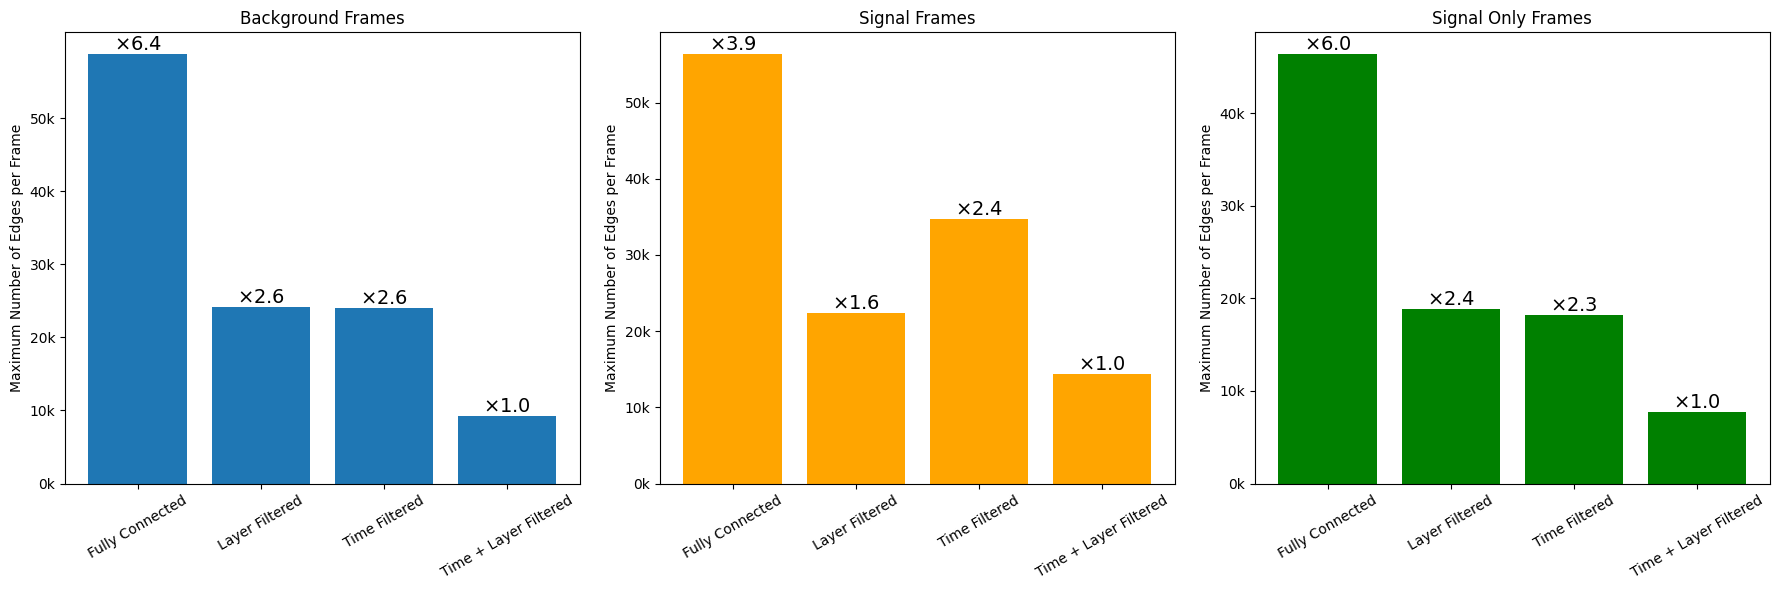

In [10]:
fig, ax = plt.subplots(1, 3, figsize=(18, 6))
edge_count = np.array([background_fully_connected_edges.max(), background_layer_filtered_edges.max(), background_time_filtered_edges.max(), background_time_layer_filtered_edges.max()])
ax[0].bar(np.arange(4), edge_count)
ax[0].set_ylabel('Maximum Number of Edges per Frame')
ax[0].set_title('Background Frames')
ax[0].set_xticks(np.arange(4))
ax[0].set_xticklabels(['Fully Connected', 'Layer Filtered', 'Time Filtered', 'Time + Layer Filtered'], rotation=30)
y_ticks = np.arange(1, np.ceil(np.max(edge_count) + 500), step=10000)
ax[0].set_yticks(y_ticks)
ax[0].set_yticklabels([f"{int(y/1000)}k" for y in y_ticks])


# Annotate each bar with the difference to the time+layer filtered version
for i in range(4):
    factor = edge_count[i] / edge_count[3]
    ax[0].text(i, edge_count[i], r"$\times$" + f"{factor:.1f}", ha='center', va='bottom', fontsize=14)

edge_count = np.array([signal_fully_connected_edges.max(), signal_layer_filtered_edges.max(), signal_time_filtered_edges.max(), signal_time_layer_filtered_edges.max()])
ax[1].bar(np.arange(4), edge_count, color='orange')
ax[1].set_ylabel('Maximum Number of Edges per Frame')
ax[1].set_title('Signal Frames')
ax[1].set_xticks(np.arange(4))
ax[1].set_xticklabels(['Fully Connected', 'Layer Filtered', 'Time Filtered', 'Time + Layer Filtered'], rotation=30)
for i in range(4):
    factor = edge_count[i] / edge_count[3]
    ax[1].text(i, edge_count[i], r"$\times$" + f"{factor:.1f}", ha='center', va='bottom', fontsize=14)
ax[1].set_yticks(np.arange(0, np.ceil(np.max(edge_count) + 500), step=1000))
y_ticks = np.arange(1, np.ceil(np.max(edge_count) + 500), step=10000)
ax[1].set_yticks(y_ticks)
ax[1].set_yticklabels([f"{int(y/1000)}k" for y in y_ticks])

edge_count = np.array([signal_only_fully_connected_edges.max(), signal_only_layer_filtered_edges.max(), signal_only_time_filtered_edges.max(), signal_only_time_layer_filtered_edges.max()])
ax[2].bar(np.arange(4), edge_count, color='green')
ax[2].set_ylabel('Maximum Number of Edges per Frame')
ax[2].set_title('Signal Only Frames')
ax[2].set_xticks(np.arange(4))
ax[2].set_xticklabels(['Fully Connected', 'Layer Filtered', 'Time Filtered', 'Time + Layer Filtered'], rotation=30)
for i in range(4):
    factor = edge_count[i] / edge_count[3]
    ax[2].text(i, edge_count[i], r"$\times$" + f"{factor:.1f}", ha='center', va='bottom', fontsize=14)
y_ticks = np.arange(1, np.ceil(np.max(edge_count) + 500), step=10000)
ax[2].set_yticks(y_ticks)
ax[2].set_yticklabels([f"{int(y/1000)}k" for y in y_ticks])

plt.tight_layout()
plt.show()

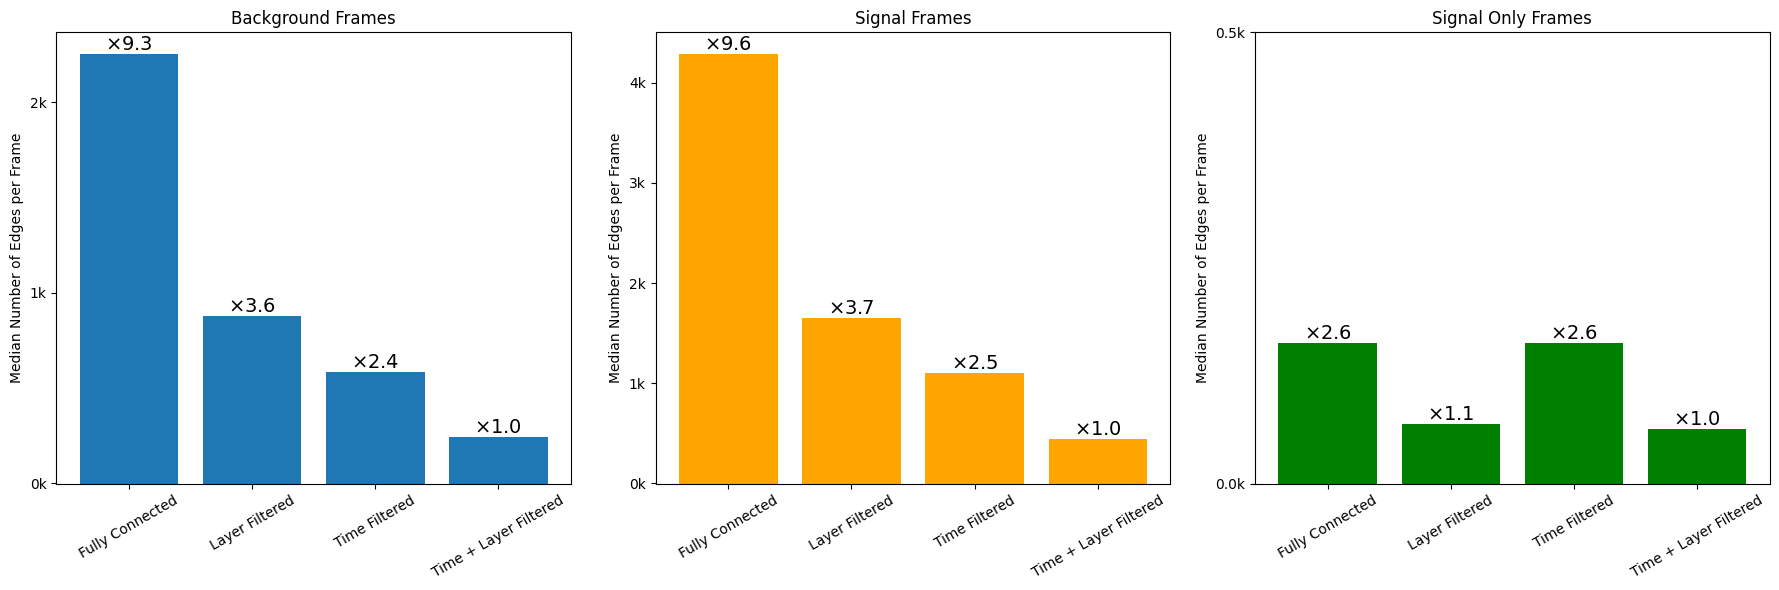

In [11]:
fig, ax = plt.subplots(1, 3, figsize=(18, 6))
edge_count = np.array([np.median(background_fully_connected_edges), np.median(background_layer_filtered_edges), np.median(background_time_filtered_edges), np.median(background_time_layer_filtered_edges)])
ax[0].bar(np.arange(4), edge_count)
ax[0].set_ylabel('Median Number of Edges per Frame')
ax[0].set_title('Background Frames')
ax[0].set_xticks(np.arange(4))
ax[0].set_xticklabels(['Fully Connected', 'Layer Filtered', 'Time Filtered', 'Time + Layer Filtered'], rotation=30)
y_ticks = np.arange(1, np.ceil(np.max(edge_count) + 500), step=1000)
ax[0].set_yticks(y_ticks)
ax[0].set_yticklabels([f"{int(y/1000)}k" for y in y_ticks])


# Annotate each bar with the difference to the time+layer filtered version
for i in range(4):
    factor = edge_count[i] / edge_count[3]
    ax[0].text(i, edge_count[i], r"$\times$" + f"{factor:.1f}", ha='center', va='bottom', fontsize=14)

edge_count = np.array([np.median(signal_fully_connected_edges), np.median(signal_layer_filtered_edges), np.median(signal_time_filtered_edges), np.median(signal_time_layer_filtered_edges)])
ax[1].bar(np.arange(4), edge_count, color='orange')
ax[1].set_ylabel('Median Number of Edges per Frame')
ax[1].set_title('Signal Frames')
ax[1].set_xticks(np.arange(4))
ax[1].set_xticklabels(['Fully Connected', 'Layer Filtered', 'Time Filtered', 'Time + Layer Filtered'], rotation=30)
for i in range(4):
    factor = edge_count[i] / edge_count[3]
    ax[1].text(i, edge_count[i], r"$\times$" + f"{factor:.1f}", ha='center', va='bottom', fontsize=14)
y_ticks = np.arange(1, np.ceil(np.max(edge_count) + 500), step=1000)
ax[1].set_yticks(y_ticks)
ax[1].set_yticklabels([f"{int(y/1000)}k" for y in y_ticks])

edge_count = np.array([np.median(signal_only_fully_connected_edges), np.median(signal_only_layer_filtered_edges), np.median(signal_only_time_filtered_edges), np.median(signal_only_time_layer_filtered_edges)])
ax[2].bar(np.arange(4), edge_count, color='green')
ax[2].set_ylabel('Median Number of Edges per Frame')
ax[2].set_title('Signal Only Frames')
ax[2].set_xticks(np.arange(4))
ax[2].set_xticklabels(['Fully Connected', 'Layer Filtered', 'Time Filtered', 'Time + Layer Filtered'], rotation=30)
for i in range(4):
    factor = edge_count[i] / edge_count[3]
    ax[2].text(i, edge_count[i], r"$\times$" + f"{factor:.1f}", ha='center', va='bottom', fontsize=14)
y_ticks = np.arange(0, np.ceil(np.max(edge_count) + 500), step=500)
ax[2].set_yticks(y_ticks)
ax[2].set_yticklabels([f"{float(y/1000)}k" for y in y_ticks])

plt.tight_layout()
plt.show()